In [17]:
# --- Celda 1: Importaciones y Carga de Datos ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# Configuración visual
sns.set_theme(style="whitegrid")
colors = ["#4C72B0", "#DD8452"]  # Azul (Abiertos) y Naranja (Cerrados) para mantener consistencia
sns.set_palette(sns.color_palette(colors))

# Cargar los features topológicos
df_gsp = pd.read_csv('./data/features/features_gsp.csv')
df_tsp = pd.read_csv('./data/features/features_tsp.csv')

# Mapear etiquetas para mejor visualización
label_map = {0: 'Ojos Abiertos (0)', 1: 'Ojos Cerrados (1)'}
df_gsp['Estado'] = df_gsp['label'].map(label_map)
df_tsp['Estado'] = df_tsp['label'].map(label_map)

print(f"Dataset GSP cargado: {df_gsp.shape}")
print(f"Dataset TSP cargado: {df_tsp.shape}")
print(f"Distribución de clases:\n{df_gsp['Estado'].value_counts()}")

Dataset GSP cargado: (231, 6)
Dataset TSP cargado: (231, 6)
Distribución de clases:
Estado
Ojos Abiertos (0)    125
Ojos Cerrados (1)    106
Name: count, dtype: int64


In [18]:
# --- Celda 2: Motor de Visualización y Test Estadístico ---

def plot_topological_features(df, features, title_prefix=""):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, feat in enumerate(features):
        ax = axes[i]
        
        # Generar Boxplot
        sns.boxplot(data=df, x='Estado', y=feat, ax=ax, width=0.5, 
                    boxprops=dict(alpha=0.8), flierprops=dict(marker='o', markersize=4))
        
        # Test estadístico (Mann-Whitney U)
        class_0 = df[df['label'] == 0][feat]
        class_1 = df[df['label'] == 1][feat]
        stat, p_value = mannwhitneyu(class_0, class_1, alternative='two-sided')
        
        # Formatear el título del subplot
        ax.set_title(f"{feat}\n(p-value: {p_value:.2e})", fontsize=12, fontweight='bold')
        ax.set_xlabel("")
        ax.set_ylabel("Valor")
        
    plt.suptitle(f'Análisis Exploratorio: {title_prefix}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

>>> Evaluando Separabilidad de Características GSP <<<


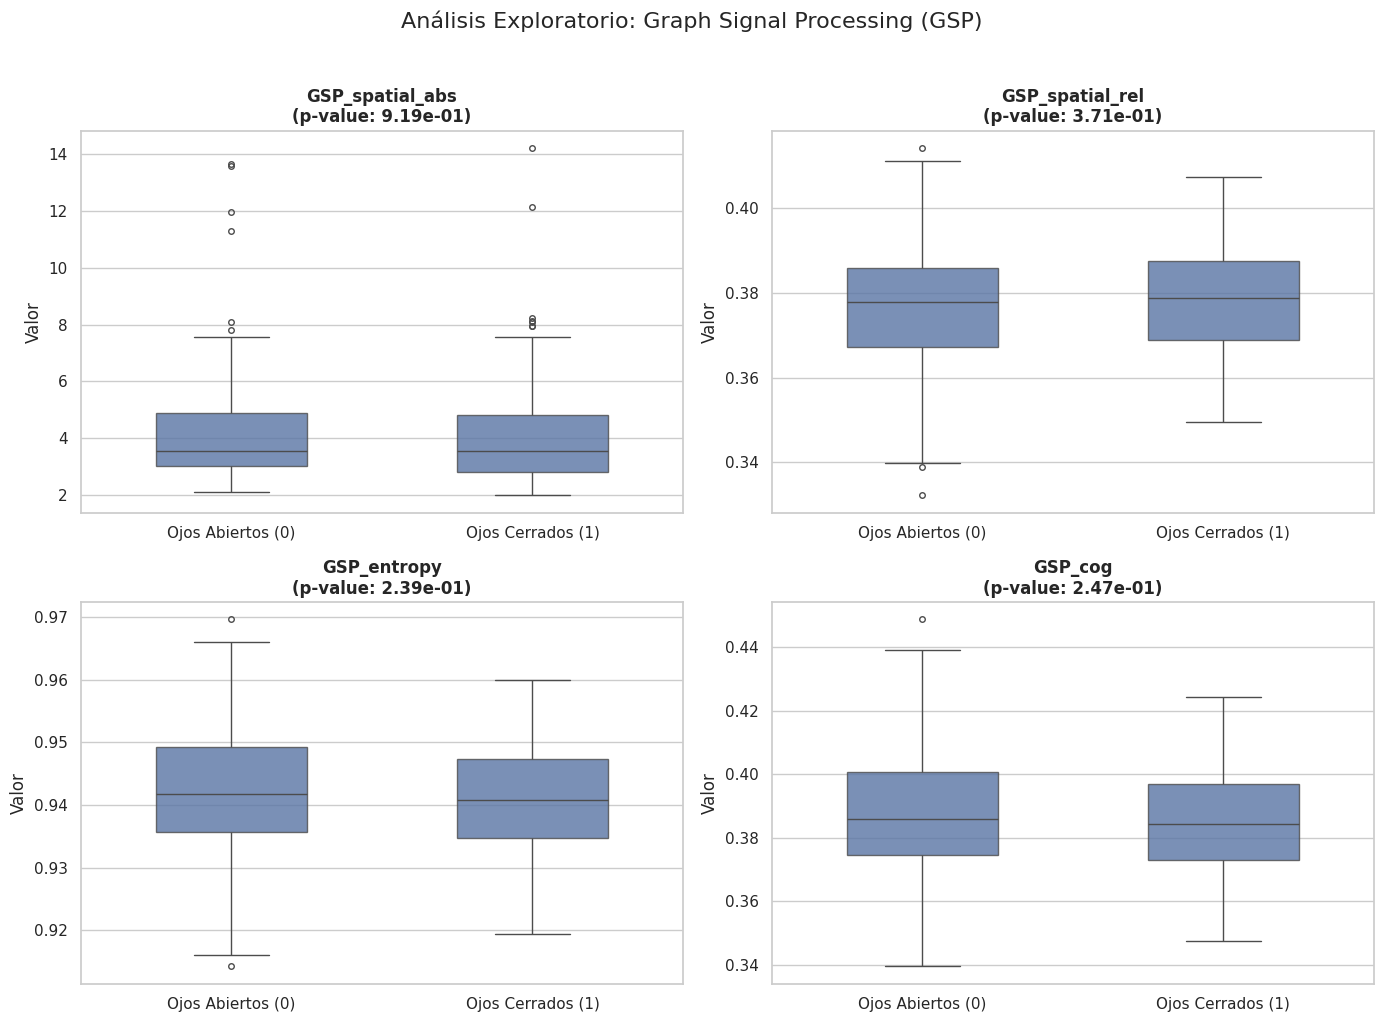

In [19]:
# --- Celda 3: Boxplots GSP ---

gsp_features = [
    'GSP_spatial_abs', 
    'GSP_spatial_rel', 
    'GSP_entropy', 
    'GSP_cog'
]

print(">>> Evaluando Separabilidad de Características GSP <<<")
plot_topological_features(df_gsp, gsp_features, title_prefix="Graph Signal Processing (GSP)")

>>> Evaluando Separabilidad de Características TSP <<<


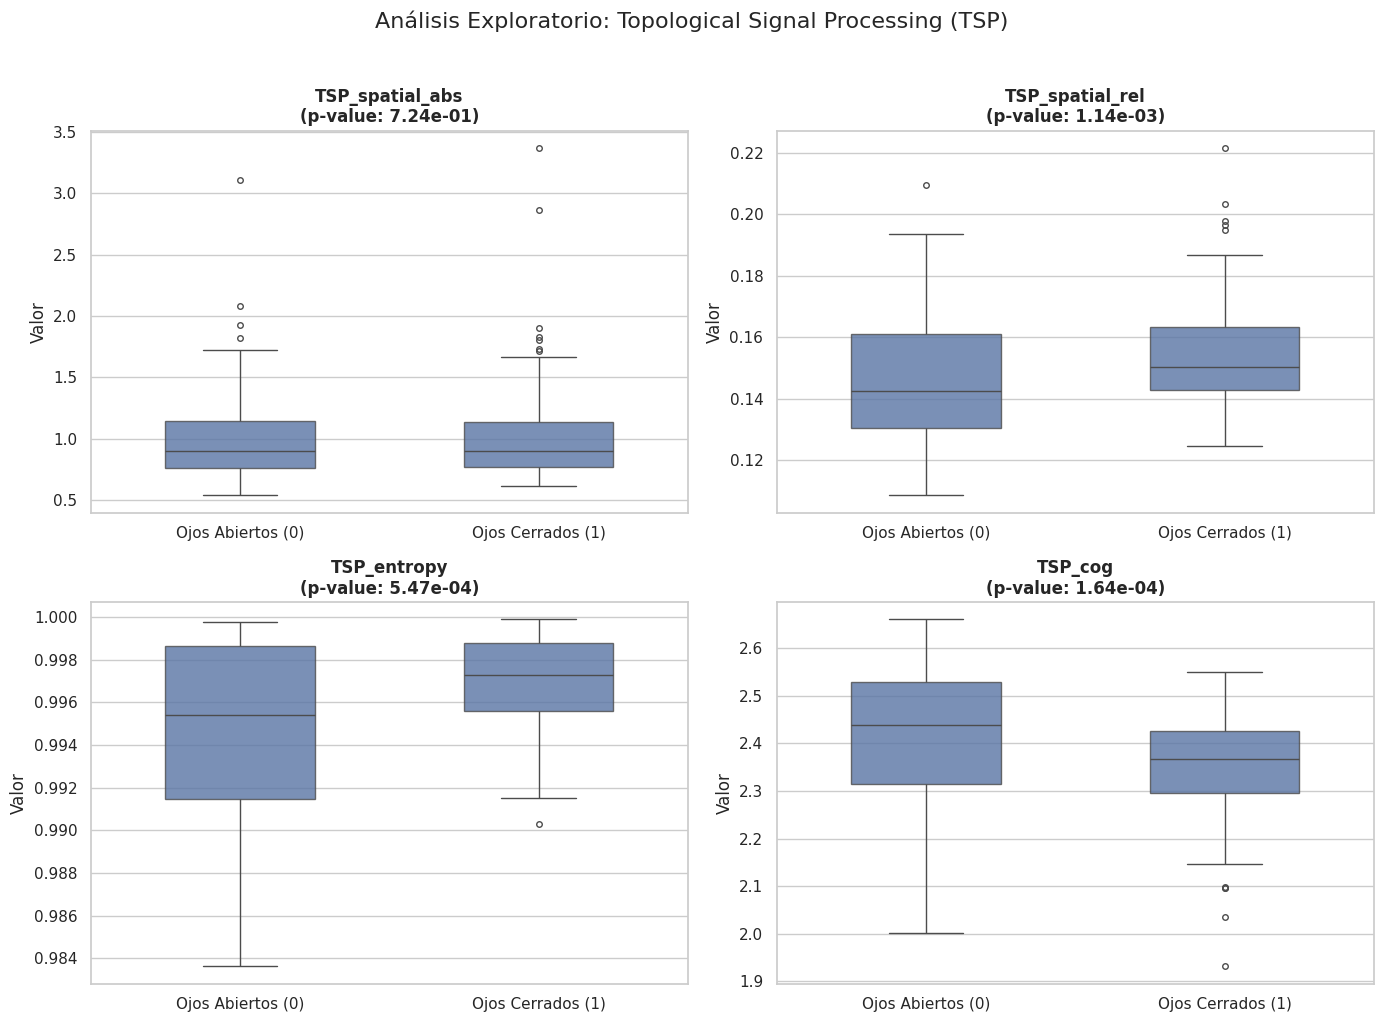

In [20]:
# --- Celda 4: Boxplots TSP ---

tsp_features = [
    'TSP_spatial_abs', 
    'TSP_spatial_rel', 
    'TSP_entropy', 
    'TSP_cog'
]

print(">>> Evaluando Separabilidad de Características TSP <<<")
plot_topological_features(df_tsp, tsp_features, title_prefix="Topological Signal Processing (TSP)")